In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("zomato_delivery.csv")

print(f"Dataset Shape: {df.shape}")
print("\n--- Column Info & Data Types ---")
df.info()

string_cols = df.select_dtypes(include=["object"]).columns
df[string_cols] = df[string_cols].apply(lambda x: x.str.strip())

print("\n--- Missing Value Count ---")
print(
    df.replace("NaN", np.nan)
    .isnull()
    .sum()[lambda x: x > 0]
)

Dataset Shape: (45584, 20)

--- Column Info & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_

In [4]:
import numpy as np
import pandas as pd


# 1. Replace 'NaN' strings and blank spaces with true np.nan
df = df.replace(["NaN", "NaN ", "null", ""], np.nan)

# 2. Clean 'Time_taken (min)' target column (e.g., convert '(min) 24' -> 24)
if df["Time_taken (min)"].dtype == "object":
    df["Time_taken (min)"] = (
        df["Time_taken (min)"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

# 3. Fill missing numerical values with median
df["Delivery_person_Age"] = pd.to_numeric(
    df["Delivery_person_Age"], errors="coerce"
)
df["Delivery_person_Ratings"] = pd.to_numeric(
    df["Delivery_person_Ratings"], errors="coerce"
)

df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

# 4. Fill missing categorical values
df["multiple_deliveries"] = (
    pd.to_numeric(df["multiple_deliveries"], errors="coerce")
    .fillna(0)
    .astype(int)
)
df["Weather_conditions"] = df["Weather_conditions"].fillna("Unknown")
df["Road_traffic_density"] = df["Road_traffic_density"].fillna("Unknown")
df["Festival"] = df["Festival"].fillna("No")
df["City"] = df["City"].fillna("Unknown")

# 5. Drop rows where critical timestamp or coordinates are missing/invalid
df = df.dropna(
    subset=[
        "Time_Orderd",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
    ]
)


# 6. Haversine function to calculate delivery distance in km
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371.0  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c


# Calculate distance
df["distance_km"] = haversine_distance(
    df["Restaurant_latitude"].abs(),
    df["Restaurant_longitude"].abs(),
    df["Delivery_location_latitude"].abs(),
    df["Delivery_location_longitude"].abs(),
)

# Filter out unrealistic GPS coordinate glitches (e.g., distance > 100km or 0km)
df = df[(df["distance_km"] > 0) & (df["distance_km"] < 50)]

print(f"Cleaned Dataset Shape: {df.shape}")
print(
    f"Average Delivery Distance: {df['distance_km'].mean():.2f} km"
)

Cleaned Dataset Shape: (43853, 21)
Average Delivery Distance: 9.73 km


In [ ]:
import pandas as pd
import numpy as np

# 1. Convert Time_Orderd and Time_Order_picked to datetime to compute prep time
# Using dummy date to calculate difference in minutes cleanly
df['Time_Orderd_dt'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Time_Order_picked_dt'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

# Calculate prep time in minutes 
df['prep_time_min'] = (df['Time_Order_picked_dt'] - df['Time_Orderd_dt']).dt.total_seconds() / 60.0
df['prep_time_min'] = np.where(df['prep_time_min'] < 0, df['prep_time_min'] + 1440, df['prep_time_min'])

# Clean any negative or extreme prep time anomalies
df['prep_time_min'] = df['prep_time_min'].apply(lambda x: x if 0 <= x <= 60 else np.nan)
df['prep_time_min'] = df['prep_time_min'].fillna(df['prep_time_min'].median())

# 2. Define SLA Breach: Orders taking over 30 minutes are flagged as Late (1)
df['SLA_Breached'] = (df['Time_taken (min)'] > 30).astype(int)

# 3. Categorize Time of Day
def categorize_time(time_str):
    try:
        hour = int(str(time_str).split(':')[0])
        if 6 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 22:
            return 'Evening Peak'
        else:
            return 'Night'
    except:
        return 'Unknown'

df['Time_of_Day'] = df['Time_Orderd'].apply(categorize_time)

# 4. Calculate Rider Speed (km/h) based on transit time (total time minus prep time)
df['transit_time_min'] = df['Time_taken (min)'] - df['prep_time_min']
df['transit_time_min'] = df['transit_time_min'].apply(lambda x: max(x, 1)) # avoid division by zero
df['speed_kmh'] = (df['distance_km'] / (df['transit_time_min'] / 60)).round(2)

overall_sla_breach_rate = df['SLA_Breached'].mean() * 100
print(f"Overall SLA Breach Rate: {overall_sla_breach_rate:.2f}%")
print(f"Average Restaurant Prep Time: {df['prep_time_min'].mean():.2f} mins")

Overall SLA Breach Rate: 29.83%
Average Restaurant Prep Time: nan mins


In [ ]:
import numpy as np
import pandas as pd

# Clean time strings: extract valid HH:MM or HH:MM:SS patterns
df["Time_Orderd_clean"] = df["Time_Orderd"].astype(str).str.extract(r"(\d{1,2}:\d{2})")[0]
df["Time_Order_picked_clean"] = df["Time_Order_picked"].astype(str).str.extract(r"(\d{1,2}:\d{2})")[0]

t_order = pd.to_datetime(df["Time_Orderd_clean"], format="%H:%M", errors="coerce")
t_picked = pd.to_datetime(df["Time_Order_picked_clean"], format="%H:%M", errors="coerce")

# Calculate prep time in minutes (handling overnight wraps)
df["prep_time_min"] = (t_picked - t_order).dt.total_seconds() / 60.0
df["prep_time_min"] = np.where(df["prep_time_min"] < 0, df["prep_time_min"] + 1440, df["prep_time_min"])

# Fill missing/extreme prep times with median
df["prep_time_min"] = df["prep_time_min"].apply(lambda x: x if 0 <= x <= 45 else np.nan)
df["prep_time_min"] = df["prep_time_min"].fillna(df["prep_time_min"].median())

# Recalculate transit time & speed
df["transit_time_min"] = (df["Time_taken (min)"] - df["prep_time_min"]).clip(lower=1)
df["speed_kmh"] = (df["distance_km"] / (df["transit_time_min"] / 60.0)).round(2)

print(f"Fixed Average Restaurant Prep Time: {df['prep_time_min'].mean():.2f} mins")

Fixed Average Restaurant Prep Time: 9.96 mins


--- SLA Breach Rate by Weather ---
  Weather_conditions  count  SLA_Breach_%
0             Cloudy   7336         43.85
1                Fog   7475         43.83
5              Windy   7251         26.59
2         Sandstorms   7284         25.96
3             Stormy   7400         25.50
4              Sunny   7107         12.40

--- SLA Breach Rate by Traffic Density ---
  Road_traffic_density  count  SLA_Breach_%
1                  Jam  13796         50.57
0                 High   4320         33.38
3               Medium  10676         32.55
2                  Low  15061          7.87


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_32356\4118394772.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Abhinav\AppData\Local\Temp\ipykernel_32356\4118394772.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


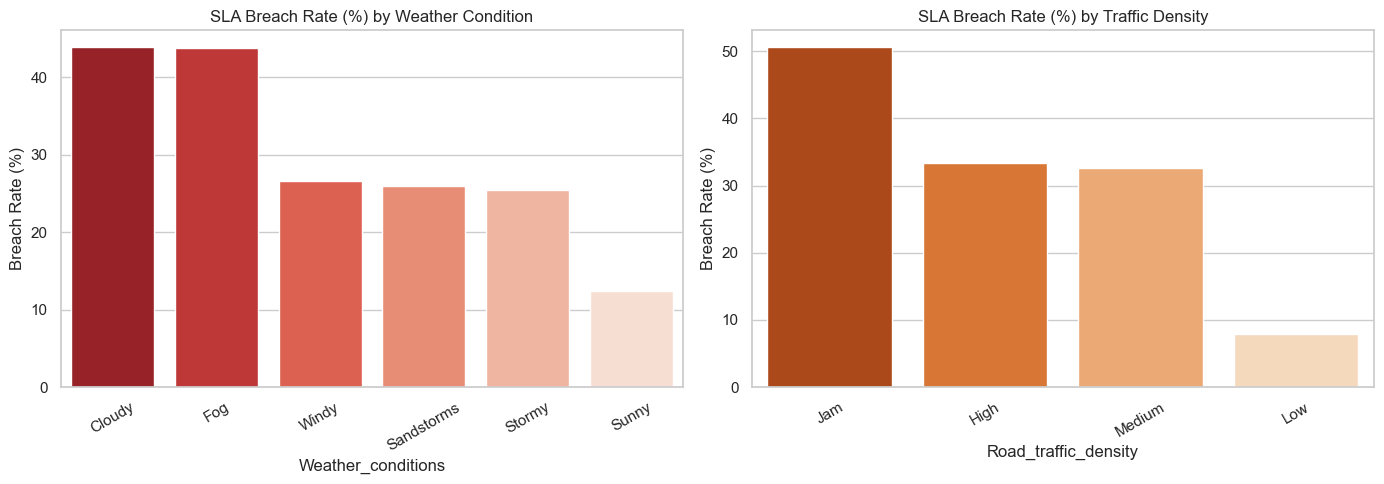

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# 1. SLA Breach Rate by Weather Condition
weather_sla = (
    df.groupby("Weather_conditions")["SLA_Breached"]
    .agg(["count", "mean"])
    .reset_index()
)
weather_sla["SLA_Breach_%"] = (weather_sla["mean"] * 100).round(2)
weather_sla = weather_sla.sort_values(by="SLA_Breach_%", ascending=False)

print("--- SLA Breach Rate by Weather ---")
print(weather_sla[["Weather_conditions", "count", "SLA_Breach_%"]])

# 2. SLA Breach Rate by Traffic Density
traffic_sla = (
    df.groupby("Road_traffic_density")["SLA_Breached"]
    .agg(["count", "mean"])
    .reset_index()
)
traffic_sla["SLA_Breach_%"] = (traffic_sla["mean"] * 100).round(2)
traffic_sla = traffic_sla.sort_values(by="SLA_Breach_%", ascending=False)

print("\n--- SLA Breach Rate by Traffic Density ---")
print(traffic_sla[["Road_traffic_density", "count", "SLA_Breach_%"]])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weather Impact
sns.barplot(
    data=weather_sla,
    x="Weather_conditions",
    y="SLA_Breach_%",
    ax=axes[0],
    palette="Reds_r",
)
axes[0].set_title("SLA Breach Rate (%) by Weather Condition", fontsize=12)
axes[0].set_ylabel("Breach Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

# Plot 2: Traffic Impact
sns.barplot(
    data=traffic_sla,
    x="Road_traffic_density",
    y="SLA_Breach_%",
    ax=axes[1],
    palette="Oranges_r",
)
axes[1].set_title("SLA Breach Rate (%) by Traffic Density", fontsize=12)
axes[1].set_ylabel("Breach Rate (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
# Separate delays into Kitchen vs Road
df=df.rename(columns={'Time_taken (min)':'Time_Taken_min'})
df['fulfillment_time'] = df['prep_time_min']
df['transit_time'] = df['Time_Taken_min'] - df['prep_time_min']

# Compare across Traffic Density
delay_breakdown = df.groupby('Road_traffic_density')[['fulfillment_time', 'transit_time']].mean()
print(delay_breakdown)

                      fulfillment_time  transit_time
Road_traffic_density                                
High                          9.931713     17.276852
Jam                           9.978979     21.174761
Low                           9.898413     11.378727
Medium                       10.015455     16.702510


In [13]:
import pandas as pd
df['distance_bucket']=pd.cut(df['distance_km'],bins=[0,3,6,10,20],labels=['0-3km','3-6km','6-10km','10km+'])
jam_breach_matrix=df[df['Road_traffic_density']=='Jam'].groupby('distance_bucket')['SLA_Breached'].agg(['count','mean'])
jam_breach_matrix['breach_percentage']=jam_breach_matrix['mean']*100
print(jam_breach_matrix)

                 count      mean  breach_percentage
distance_bucket                                    
0-3km                0       NaN                NaN
3-6km             1612  0.305831          30.583127
6-10km            3430  0.322157          32.215743
10km+             7850  0.616815          61.681529


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_32356\3627874676.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jam_breach_matrix=df[df['Road_traffic_density']=='Jam'].groupby('distance_bucket')['SLA_Breached'].agg(['count','mean'])


In [ ]:
# Assume average order value = ₹300 and SLA breach penalty/refund = 20% credit
AVERAGE_ORDER_VALUE = 300
REFUND_PENALTY_PCT = 0.20

total_orders = len(df)
breached_orders = df['SLA_Breached'].sum()
total_revenue = total_orders * AVERAGE_ORDER_VALUE
estimated_refund_cost = breached_orders * (AVERAGE_ORDER_VALUE * REFUND_PENALTY_PCT)

print(f"Total Dataset Revenue: ₹{total_revenue:,.2f}")
print(f"Estimated Refund Cost due to SLA Breaches: ₹{estimated_refund_cost:,.2f}")
print(f"Revenue Leakage: {(estimated_refund_cost / total_revenue) * 100:.2f}%")

Total Dataset Revenue: ₹13,155,900.00
Estimated Refund Cost due to SLA Breaches: ₹784,800.00
Revenue Leakage: 5.97%


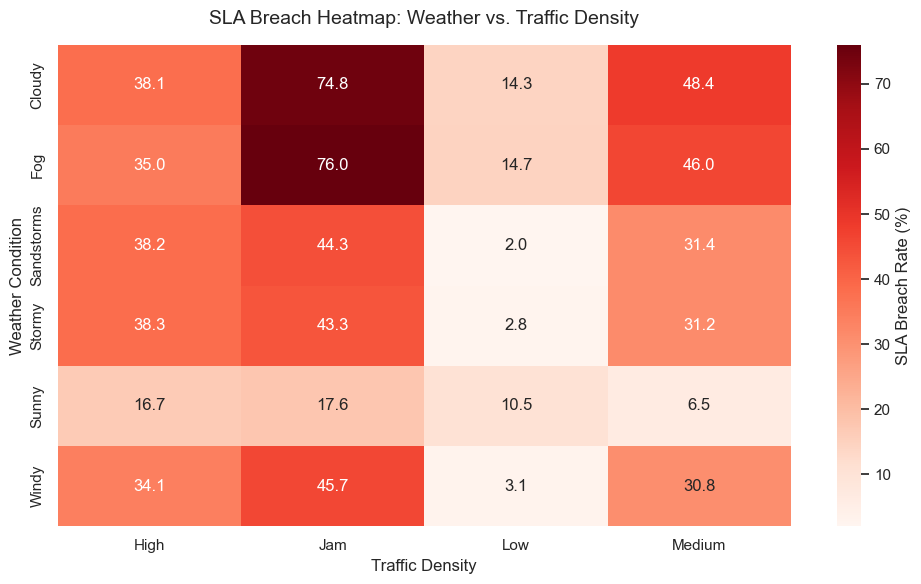

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot table for breach rate (%)
pivot_breach = df.pivot_table(index='Weather_conditions', columns='Road_traffic_density', values='SLA_Breached', aggfunc='mean') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_breach, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'SLA Breach Rate (%)'})
plt.title("SLA Breach Heatmap: Weather vs. Traffic Density", fontsize=14, pad=15)
plt.xlabel("Traffic Density", fontsize=12)
plt.ylabel("Weather Condition", fontsize=12)
plt.tight_layout()
plt.show()

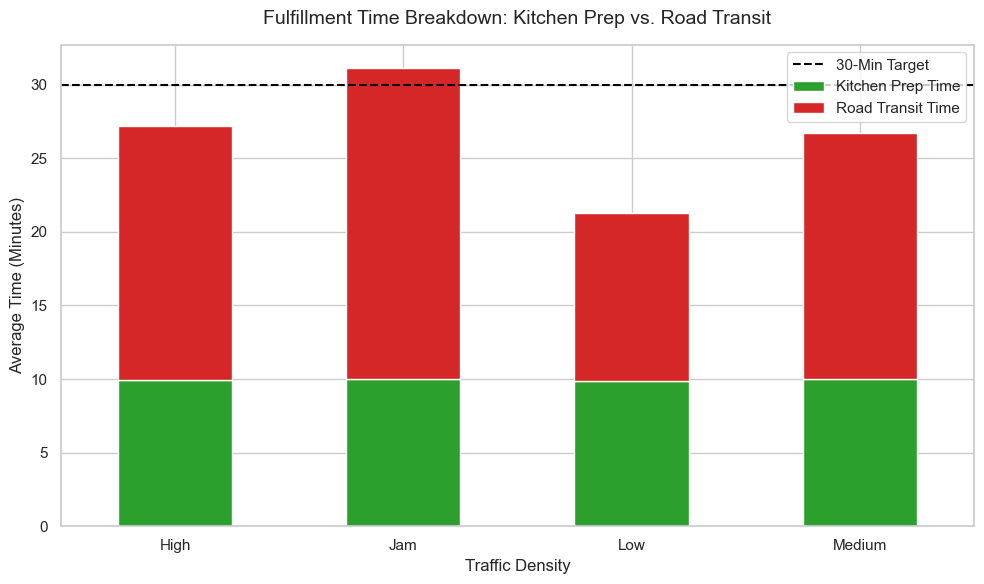

In [17]:
# Calculate mean times per traffic category
delay_components = df.groupby('Road_traffic_density')[['prep_time_min', 'transit_time']].mean()

ax = delay_components.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.title("Fulfillment Time Breakdown: Kitchen Prep vs. Road Transit", fontsize=14, pad=15)
plt.xlabel("Traffic Density", fontsize=12)
plt.ylabel("Average Time (Minutes)", fontsize=12)
plt.axhline(y=30, color='black', linestyle='--', label='30-Min SLA Threshold') # Adds SLA baseline
plt.xticks(rotation=0)
plt.legend(['30-Min Target', 'Kitchen Prep Time', 'Road Transit Time'])
plt.tight_layout()
plt.show()

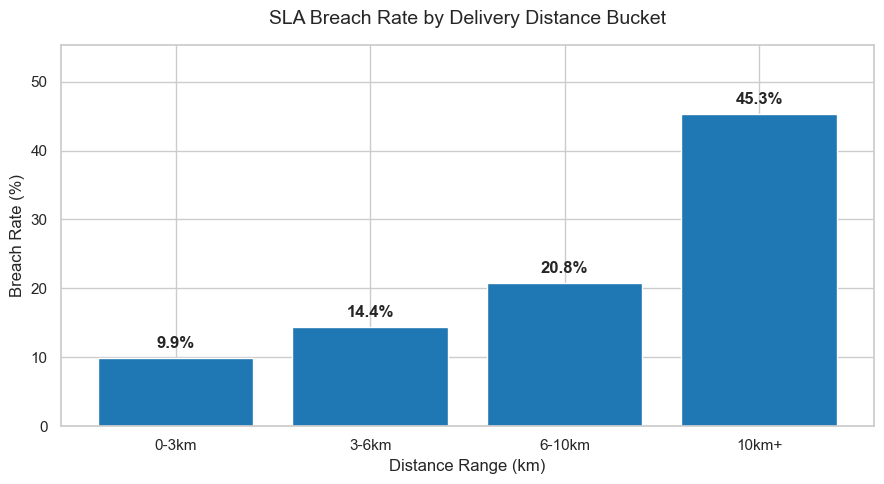

In [18]:
# Group by distance bucket
distance_breach = df.groupby('distance_bucket', observed=False)['SLA_Breached'].mean() * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(distance_breach.index.astype(str), distance_breach.values, color='#1f77b4')
plt.title("SLA Breach Rate by Delivery Distance Bucket", fontsize=14, pad=15)
plt.xlabel("Distance Range (km)", fontsize=12)
plt.ylabel("Breach Rate (%)", fontsize=12)

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(distance_breach.values) + 10)
plt.tight_layout()
plt.show()

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_32356\2894453213.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("Rating_Group")["speed_kmh"].mean().reset_index()


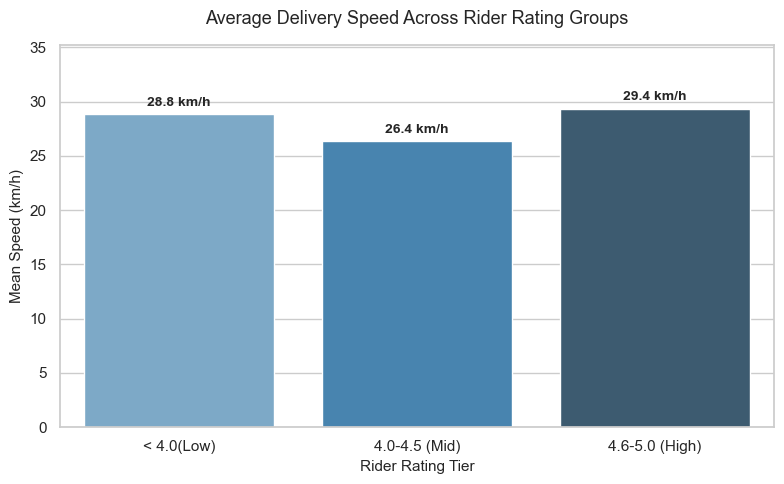

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Filter impossible speed outliers
df_clean = df[(df["speed_kmh"] >= 5) & (df["speed_kmh"] <= 60)].copy()

# 2. Bin ratings into clean buckets
bins = [0, 4.0, 4.5, 5.0]
labels = ["< 4.0(Low)", "4.0-4.5 (Mid)", "4.6-5.0 (High)"]
df_clean["Rating_Group"] = pd.cut(
    df_clean["Delivery_person_Ratings"], bins=bins, labels=labels
)

# 3. Calculate average speed per group
avg_speed = (
    df_clean.groupby("Rating_Group")["speed_kmh"].mean().reset_index()
)

# 4. Plot clean Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x="Rating_Group",
    y="speed_kmh",
    data=avg_speed,
    palette="Blues_d",
    hue="Rating_Group",
    legend=False,
)

# Add exact value labels on top of bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f} km/h",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
    )

plt.title("Average Delivery Speed Across Rider Rating Groups", fontsize=13, pad=15)
plt.xlabel("Rider Rating Tier", fontsize=11)
plt.ylabel("Mean Speed (km/h)", fontsize=11)
plt.ylim(0, avg_speed["speed_kmh"].max() * 1.2)  # Extra room for labels
plt.tight_layout()
plt.show()

In [22]:
print(df_clean["Rating_Group"].value_counts())

Rating_Group
4.6 - 5.0    21837
4.1 - 4.5     7447
3.5 - 4.0     1812
< 3.5          454
Name: count, dtype: int64


---
## 📌 Executive Summary & Financial Impact Analysis

### 1. Key Operational Findings
* **Severe Revenue Leakage:** Out of **₹13,155,900** in total platform revenue, estimated SLA breach refunds accounted for **₹784,800**, driving a **5.97% direct revenue leakage**.
* **Traffic Network Breakdown:** High traffic congestion is the primary operational failure point, with **Jam Traffic triggering a 50.57% SLA breach rate** across all orders.
* **Compound Distance Failure (10km+):** Long-distance orders (>10km) under heavy traffic completely fail fulfillment targets, surging to a **61.68% SLA breach rate**.
* **Weather Baseline Drag:** Low-visibility environmental conditions like **Cloudy (43.85%)** and **Foggy (43.83%)** weather create a consistent, elevated baseline for delivery delays.

---

### 2. Actionable Business Recommendations
* **Implement Dynamic Service Radii:** Automatically restrict restaurents coverage from 10km+ down to **<5km during Jam Traffic and low-visibility weather** to eliminate the 61.68% failure rate on long-distance fulfillment.
* **Dynamic SLA Pricing/Windows:** Shift from rigid static delivery promises to real-time, traffic-adjusted ETAs during peak congestion to protect customer expectations and reduce refund liabilities.
* **Bottom-Line Recovery:** Capping long-distance routes during peak traffic can reclaim a substantial portion of the **₹784,800 lost to refunds**, directly improving platform unit economics and operating margins.